# Swiggy's Restaurant Recommendation System using Streamlit

**Domain:** Recommendation Systems and Data Analytics

**Problem Statement:** Build a recommendation system based on restaurant data provided in a CSV
file. The system recommends restaurants to users based on input features such as city, rating,
cost, and cuisine preferences, using clustering / similarity measures, and displays results
through a Streamlit interface.

**Pipeline covered in this notebook:**
1. Data Understanding and Cleaning
2. Exploratory Data Analysis
3. Data Preprocessing (Encoding)
4. Recommendation Methodology (Clustering + Cosine Similarity)
5. Evaluation of the recommendation engine
6. Artifacts exported for the Streamlit app: `cleaned_data.csv`, `encoded_data.csv`,
   `encoder.pkl`, `kmeans_model.pkl`


In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1. Data Understanding and Cleaning

### 1.1 Load the raw dataset

In [2]:
df = pd.read_csv('swiggy.csv')
print("Shape:", df.shape)
df.head()


Shape: (148541, 11)


,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
0,567335,AB FOODS POINT,Abohar,--,Too Few Ratings,₹ 200,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json
1,531342,Janta Sweet House,Abohar,4.4,50+ ratings,₹ 200,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json
2,158203,theka coffee desi,Abohar,3.8,100+ ratings,₹ 100,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json
3,187912,Singh Hut,Abohar,3.7,20+ ratings,₹ 250,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json
4,543530,GRILL MASTERS,Abohar,--,Too Few Ratings,₹ 250,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 148541 entries, 0 to 148540
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            148541 non-null  int64
 1   name          148455 non-null  str  
 2   city          148541 non-null  str  
 3   rating        148455 non-null  str  
 4   rating_count  148455 non-null  str  
 5   cost          148410 non-null  str  
 6   cuisine       148442 non-null  str  
 7   lic_no        148312 non-null  str  
 8   link          148541 non-null  str  
 9   address       148455 non-null  str  
 10  menu          148541 non-null  str  
dtypes: int64(1), str(10)
memory usage: 53.1 MB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,148541.0,NaN,NaN,NaN,363466.378912,167890.977174,211.0,233320.0,412628.0,502223.0,581031.0
name,148455,112818,Domino's Pizza,442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,148541,821,Bikaner,1666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,148455,42,--,87014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating_count,148455,8,Too Few Ratings,87014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost,148410,363,₹ 200,38635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine,148442,2132,"North Indian,Chinese",6471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lic_no,148312,108763,license,12861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
link,148541,148541,https://www.swiggy.com/restaurants/ab-foods-po...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
address,148455,148401,"Gold Star Biryani, RS Road Dindigul - 624001",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Missing value overview

Several columns (`name`, `rating`, `rating_count`, `cost`, `cuisine`, `address`) have missing
values. We check whether these are scattered independently, or whether the same rows are
missing across the board (which would mean those rows carry essentially no usable
information).

lic_no          229
cost            131
cuisine          99
rating           86
address          86
name             86
rating_count     86
dtype: int64


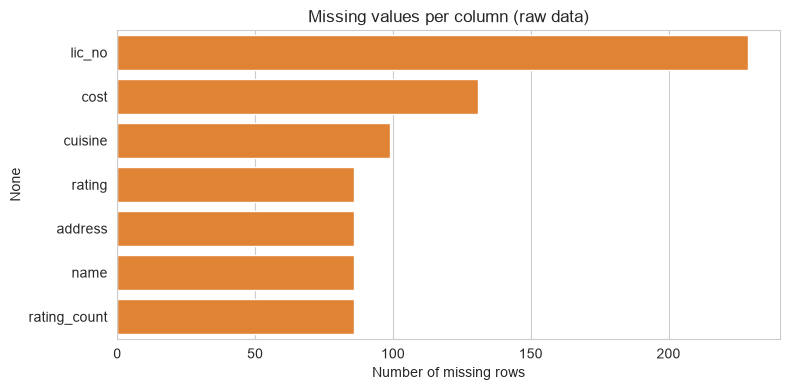

In [5]:
null_counts = df.isnull().sum().sort_values(ascending=False)
null_counts = null_counts[null_counts > 0]
print(null_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=null_counts.values, y=null_counts.index, color='#fc8019')
plt.title('Missing values per column (raw data)')
plt.xlabel('Number of missing rows')
plt.tight_layout()
plt.show()


In [6]:
core_cols = ['name', 'rating', 'rating_count', 'cost', 'cuisine', 'address']
fully_blank = df[core_cols].isnull().all(axis=1)
print(f"Rows with ALL of {core_cols} missing: {fully_blank.sum()}")
df[fully_blank].head()


Rows with ALL of ['name', 'rating', 'rating_count', 'cost', 'cuisine', 'address'] missing: 86


,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
31044,397961,NaN,"Greater Mohali,Chandigarh",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/5-tara-grea...,NaN,Menu/397961.json
32912,308071,NaN,"West Chd,Chandigarh",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/food-under-...,NaN,Menu/308071.json
33046,308662,NaN,"West Chd,Chandigarh",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/franks-frie...,NaN,Menu/308662.json
33488,170889,NaN,"South Chd,Chandigarh",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/dhaba-7-pre...,NaN,Menu/170889.json
36492,390394,NaN,"George Town,Chennai",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/frozen-cafe...,NaN,Menu/390394.json


These rows have no name, no rating, no cost, no cuisine and no address &mdash; there is
nothing meaningful left to impute or recommend, so they are dropped outright rather than
imputed. Every other missing value is handled with a **reasonable, context-aware imputation**
further down, instead of being dropped.

In [7]:
df = df.loc[~fully_blank].copy()
print("Shape after dropping fully-blank rows:", df.shape)


Shape after dropping fully-blank rows: (148455, 11)


### 1.3 Duplicate removal

In [8]:
print("Fully duplicate rows:", df.duplicated().sum())
print("Duplicate 'id' values:", df['id'].duplicated().sum())

df = df.drop_duplicates(subset=['id']).reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)


Fully duplicate rows: 0
Duplicate 'id' values: 0
Shape after duplicate removal: (148455, 11)


### 1.4 Cleaning `rating`

Swiggy uses `'--'` as a sentinel for restaurants without enough ratings yet (confirmed by it
lining up exactly with `rating_count == 'Too Few Ratings'`). We convert it to `NaN` so it can
go through the same reasonable-imputation step as any other missing rating, rather than being
treated as a valid numeric rating of zero.

In [9]:
print(df['rating'].value_counts().head(10))
print()
print("'--' count:", (df['rating'] == '--').sum())
print("'Too Few Ratings' count:", (df['rating_count'] == 'Too Few Ratings').sum())

df['rating'] = df['rating'].replace('--', np.nan).astype(float)


rating
--     87014
4.0     6532
4.1     6296
4.2     5821
3.8     5736
3.9     5435
4.3     5011
3.7     4253
4.4     3149
3.5     2963
Name: count, dtype: int64

'--' count: 87014
'Too Few Ratings' count: 87014


### 1.5 Cleaning `rating_count`

`rating_count` is a bucketed string (`'20+ ratings'`, `'1K+ ratings'`, `'Too Few Ratings'`,
etc.), not a number. We parse it into a numeric lower-bound proxy (`rating_count_num`) so it can
be used as a numerical feature in clustering/similarity. `'Too Few Ratings'` becomes `0`, which
is consistent with how we will treat the matching `NaN` rating above.

In [10]:
def parse_rating_count(x):
    if pd.isnull(x):
        return np.nan
    x = str(x).strip()
    if x == 'Too Few Ratings':
        return 0.0
    m = re.match(r'([\d.]+)K\+', x)
    if m:
        return float(m.group(1)) * 1000
    m = re.match(r'(\d+)\+', x)
    if m:
        return float(m.group(1))
    return np.nan

df['rating_count_num'] = df['rating_count'].apply(parse_rating_count)
df[['rating_count', 'rating_count_num']].drop_duplicates().sort_values('rating_count_num')


,rating_count,rating_count_num
0,Too Few Ratings,0.0
3,20+ ratings,20.0
1,50+ ratings,50.0
2,100+ ratings,100.0
88,500+ ratings,500.0
133,1K+ ratings,1000.0
6489,5K+ ratings,5000.0
71679,10K+ ratings,10000.0


### 1.6 Cleaning `cost`

`cost` is a string like `'₹ 200'`. We strip the currency symbol and convert to numeric. A quick
look at the extremes reveals a single-row data-entry error (₹300,350 for a restaurant) and a
small number of implausible near-zero values &mdash; genuine "cost for two" prices for a
restaurant realistically fall well within ₹20&ndash;₹10,000. Rather than statistically clipping
(which would distort thousands of legitimately expensive restaurants), we treat only values
**outside this plausible business range** as missing, and let them flow into the same
group-wise imputation as any other missing cost.

In [11]:
df['cost'] = pd.to_numeric(
    df['cost'].astype(str).str.replace('₹', '', regex=False).str.strip(),
    errors='coerce'
)
print(df['cost'].describe())
print()
print("Top 5 highest cost rows:")
print(df.nlargest(5, 'cost')[['name', 'city', 'cost']])


count    148410.000000
mean        287.600714
std         796.730688
min           1.000000
25%         200.000000
50%         250.000000
75%         300.000000
max      300350.000000
Name: cost, dtype: float64

Top 5 highest cost rows:
                          name                       city      cost
70746           KOHINOOR HOTEL                 Hinganghat  300350.0
21626         Oasis restaurant  Electronic City,Bangalore    8000.0
47545   VENOM CLUB AND KITCHEN      Hathibarkala,Dehradun    6000.0
47810     Aggarwal sweet india            GTB Nagar,Delhi    5023.0
107724        SHAAN RESTAURANT               Vashi,Mumbai    5000.0


In [12]:
LOW, HIGH = 20, 10000
n_invalid = ((df['cost'] < LOW) | (df['cost'] > HIGH)).sum()
print(f"Cost values outside plausible range [{LOW}, {HIGH}]: {n_invalid} (set to NaN for imputation)")
df.loc[(df['cost'] < LOW) | (df['cost'] > HIGH), 'cost'] = np.nan


Cost values outside plausible range [20, 10000]: 215 (set to NaN for imputation)


### 1.7 Cleaning `cuisine`

Inspecting the unique cuisine tags reveals that promotional/marketing text has leaked into this
column (e.g. `'Free Delivery ! Limited Stocks!'`, `'Code valid on bill over Rs.99'`, timing
strings like `'8:15 To 11:30 Pm'`, and placeholders like `'Default'`). These are not cuisines
and would corrupt the multi-label encoding, so they are filtered out tag-by-tag (a restaurant
that has one real cuisine tag and one junk tag keeps the real one). Casing is also
standardized so `'indian'` and `'Indian'` aren't treated as different cuisines.

In [13]:
all_tags = set()
for c in df['cuisine'].dropna():
    for t in c.split(','):
        all_tags.add(t.strip())
print(f"Unique raw cuisine tags: {len(all_tags)}")

suspicious = [t for t in all_tags if re.search(
    r'discount|offer|free delivery|code\b|combo|limited stock|avail|\d{1,2}:\d{2}',
    t, re.IGNORECASE)]
print("Promotional / junk-looking tags found:")
for t in suspicious:
    print(" -", t)


Unique raw cuisine tags: 126
Promotional / junk-looking tags found:
 - 8:15 To 11:30 Pm
 - MAX 2 Combos per Order!
 - Discount offer from Garden Cafe Express Kankurgachi
 - Code valid on bill over Rs.99
 - Use code XPRESS121 to avail.
 - Use Code JUMBO30 to avail
 - Attractive Combos Available
 - Combo
 - Free Delivery ! Limited Stocks!
 - Special Discount from (Hotel Swagath)


In [14]:
JUNK_EXACT = {'default', 'popular brand store', 'navratri special', 'svanidhi street food vendor'}
PROMO_PATTERN = re.compile(r'discount|offer|free delivery|code\b|combo|limited stock|avail', re.IGNORECASE)
TIME_PATTERN = re.compile(r'\d{1,2}:\d{2}')

def clean_cuisine(cell):
    """Split multi-cuisine strings, drop promotional/junk tags, normalize case,
    de-duplicate while preserving order. Returns NaN if nothing valid remains."""
    if pd.isnull(cell):
        return np.nan
    tags = [t.strip() for t in cell.split(',')]
    keep = []
    for t in tags:
        if not t:
            continue
        if t.lower() in JUNK_EXACT:
            continue
        if PROMO_PATTERN.search(t) or TIME_PATTERN.search(t):
            continue
        keep.append(t.title())
    if not keep:
        return np.nan
    seen = set()
    deduped = [t for t in keep if not (t in seen or seen.add(t))]
    return ','.join(deduped)

n_before = df['cuisine'].isnull().sum()
df['cuisine'] = df['cuisine'].apply(clean_cuisine)
n_after = df['cuisine'].isnull().sum()
print(f"Cuisine missing before junk-filtering: {n_before}")
print(f"Cuisine missing after junk-filtering (junk-only rows now NaN too): {n_after}")


Cuisine missing before junk-filtering: 13
Cuisine missing after junk-filtering (junk-only rows now NaN too): 74


### 1.8 `lic_no`

`lic_no` (FSSAI license number) is not one of the modeling features (categorical: `name`,
`city`, `cuisine`; numerical: `rating`, `rating_count`, `cost`), so it just needs to be complete
for record-keeping — missing values are filled with a placeholder rather than dropped.

In [15]:
df['lic_no'] = df['lic_no'].fillna('Not Available')


### 1.9 Reasonable imputation for the remaining missing values

For `cost`, `rating` and `cuisine`, a global fill (e.g. the overall mean) would ignore that
prices, ratings and popular cuisines vary a lot by city. Instead we impute **group-wise by
city** (median for numeric, mode for categorical), and only fall back to a global
median/mode if an entire city group has no valid values to learn from.

In [16]:
def _mode_or_nan(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

# --- cost: fill missing with the city's median cost, else the global median ---
df['cost'] = df.groupby('city')['cost'].transform(lambda s: s.fillna(s.median()))
df['cost'] = df['cost'].fillna(df['cost'].median())

# --- rating: fill missing with the city's median rating, else the global median ---
df['rating'] = df.groupby('city')['rating'].transform(lambda s: s.fillna(s.median()))
df['rating'] = df['rating'].fillna(df['rating'].median())

# --- cuisine: fill missing with the city's most common cuisine, else the global mode ---
df['cuisine'] = df.groupby('city')['cuisine'].transform(lambda s: s.fillna(_mode_or_nan(s)))
df['cuisine'] = df['cuisine'].fillna(df['cuisine'].mode().iloc[0])

# --- rating_count_num: 'Too Few Ratings' already maps to 0, so any remaining NaN means 0 too ---
df['rating_count_num'] = df['rating_count_num'].fillna(0)

print("Remaining nulls:")
print(df.isnull().sum())
print()
print("Final cleaned shape:", df.shape)


Remaining nulls:
id                  0
name                0
city                0
rating              0
rating_count        0
cost                0
cuisine             0
lic_no              0
link                0
address             0
menu                0
rating_count_num    0
dtype: int64

Final cleaned shape: (148455, 12)


### 1.10 Save the cleaned dataset

In [17]:
df = df.reset_index(drop=True)
df.to_csv('cleaned_data.csv', index=True, index_label='index')
print("Saved cleaned_data.csv:", df.shape)
df.head()


Saved cleaned_data.csv: (148455, 12)


,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu,rating_count_num
0,567335,AB FOODS POINT,Abohar,4.1,Too Few Ratings,200.0,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json,0.0
1,531342,Janta Sweet House,Abohar,4.4,50+ ratings,200.0,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json,50.0
2,158203,theka coffee desi,Abohar,3.8,100+ ratings,100.0,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json,100.0
3,187912,Singh Hut,Abohar,3.7,20+ ratings,250.0,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json,20.0
4,543530,GRILL MASTERS,Abohar,4.1,Too Few Ratings,250.0,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json,0.0


## 2. Exploratory Data Analysis

A quick look at the cleaned data to understand distributions before we encode and cluster.

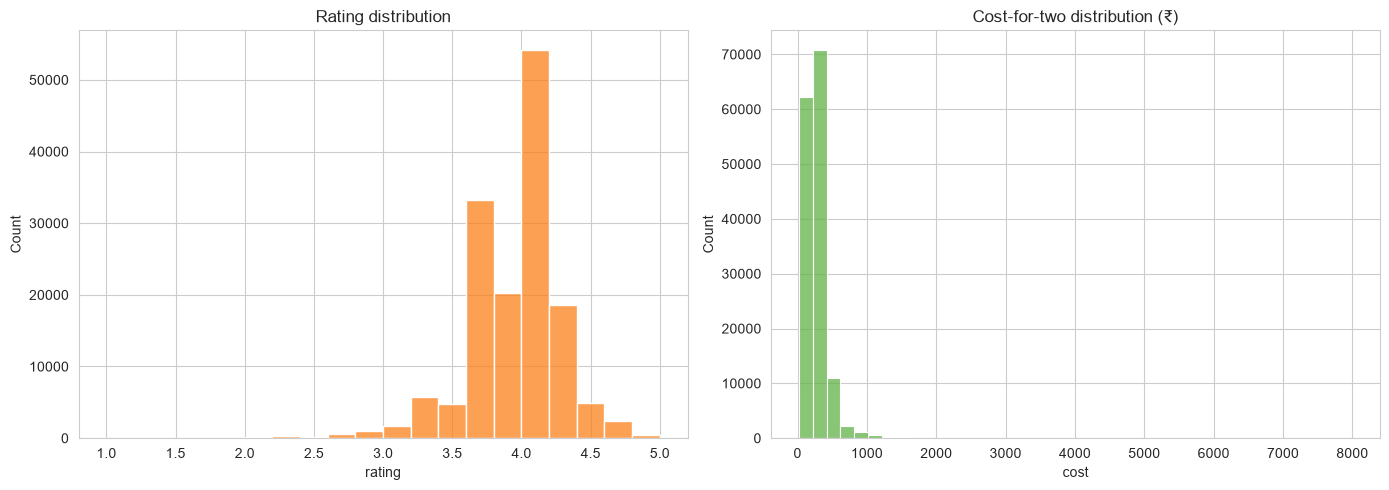

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['rating'], bins=20, kde=False, ax=axes[0], color='#fc8019')
axes[0].set_title('Rating distribution')
sns.histplot(df['cost'], bins=40, kde=False, ax=axes[1], color='#60b246')
axes[1].set_title('Cost-for-two distribution (₹)')
plt.tight_layout()
plt.show()


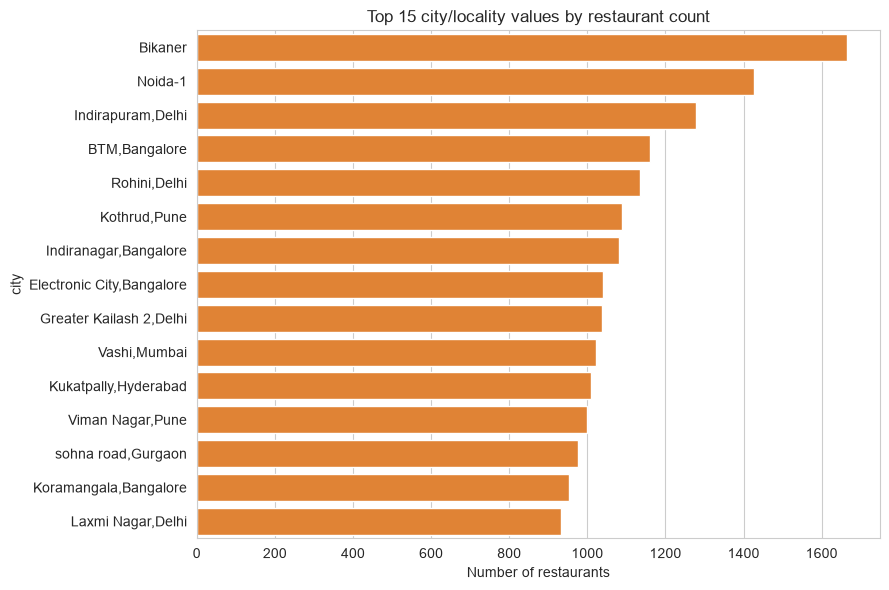

In [19]:
top_cities = df['city'].value_counts().head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, color='#fc8019')
plt.title('Top 15 city/locality values by restaurant count')
plt.xlabel('Number of restaurants')
plt.tight_layout()
plt.show()


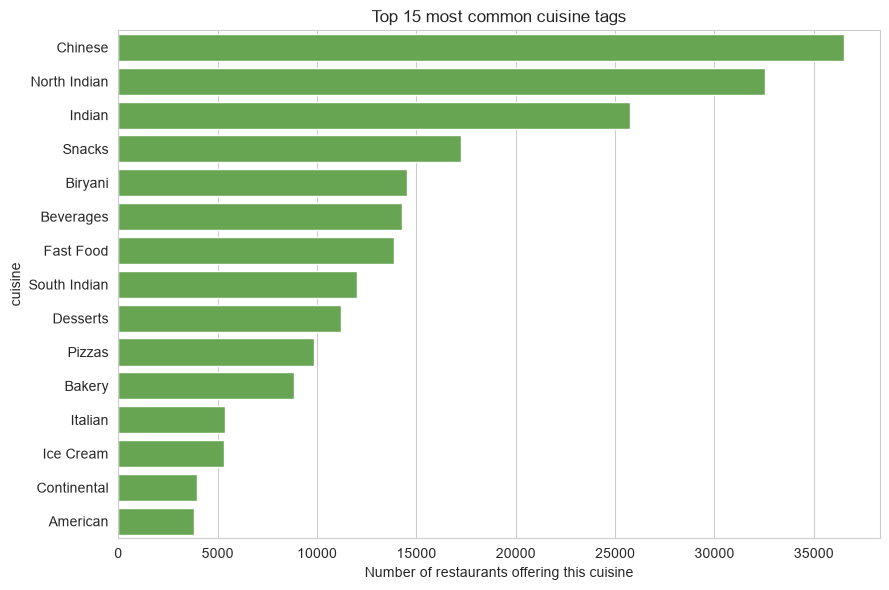

In [20]:
cuisine_flat = df['cuisine'].str.split(',').explode().str.strip()
top_cuisines = cuisine_flat.value_counts().head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, color='#60b246')
plt.title('Top 15 most common cuisine tags')
plt.xlabel('Number of restaurants offering this cuisine')
plt.tight_layout()
plt.show()


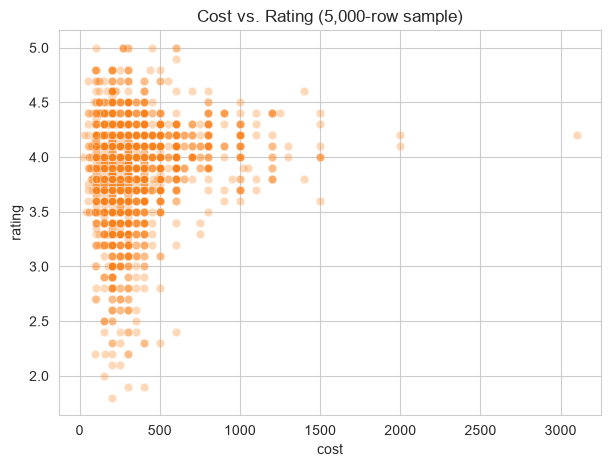

Correlation (cost, rating, rating_count_num):
                      cost    rating  rating_count_num
cost              1.000000  0.123592          0.030600
rating            0.123592  1.000000          0.063553
rating_count_num  0.030600  0.063553          1.000000


In [21]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df.sample(5000, random_state=RANDOM_SEED), x='cost', y='rating', alpha=0.3, color='#fc8019')
plt.title('Cost vs. Rating (5,000-row sample)')
plt.show()

print("Correlation (cost, rating, rating_count_num):")
print(df[['cost', 'rating', 'rating_count_num']].corr())


## 3. Data Preprocessing (Encoding)

Per the project brief: One-Hot Encode the categorical features `city` and `cuisine`, keep
`rating`, `rating_count`, `cost` numerical, and make sure `encoded_data.csv` lines up index-for-
index with `cleaned_data.csv`.

**City** has 800+ unique values (a mix of plain city names and `locality,city` combinations for
metros). One-hot encoding all of them would create an extremely wide, sparse matrix for almost
no benefit — the long tail of one-off localities carries little signal. We bucket to the
**top 150 most frequent** city values (covering ~59% of restaurants) and group the rest into
`'Other'`.

**Cuisine** is multi-valued (a restaurant can be `'North Indian,Chinese'`), so a plain
`OneHotEncoder` isn't appropriate — we use `MultiLabelBinarizer`, which is the multi-label
equivalent of one-hot encoding (a restaurant gets a `1` in every cuisine column it offers).

In [22]:
TOP_N_CITIES = 150
city_counts = df['city'].value_counts()
top_cities = city_counts.nlargest(TOP_N_CITIES).index.tolist()
coverage = city_counts.nlargest(TOP_N_CITIES).sum() / len(df)
print(f"Top {TOP_N_CITIES} cities cover {coverage:.1%} of restaurants; the rest are bucketed as 'Other'.")

df['city_bucket'] = df['city'].where(df['city'].isin(top_cities), 'Other')
print("Unique city_bucket values:", df['city_bucket'].nunique())


Top 150 cities cover 58.7% of restaurants; the rest are bucketed as 'Other'.
Unique city_bucket values: 151


In [23]:
city_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=np.int8)
city_encoded = city_ohe.fit_transform(df[['city_bucket']])
city_cols = [f"city_{c}" for c in city_ohe.categories_[0]]
print("City one-hot shape:", city_encoded.shape)


City one-hot shape: (148455, 151)


In [24]:
df['cuisine_list'] = df['cuisine'].apply(lambda s: [t.strip() for t in s.split(',')])

mlb = MultiLabelBinarizer()
cuisine_encoded = mlb.fit_transform(df['cuisine_list']).astype(np.int8)
cuisine_cols = [f"cuisine_{c}" for c in mlb.classes_]
print("Cuisine multi-hot shape:", cuisine_encoded.shape, "| unique cuisine tags:", len(mlb.classes_))


Cuisine multi-hot shape: (148455, 111) | unique cuisine tags: 111


In [25]:
num_cols = ['rating', 'rating_count_num', 'cost']
scaler = StandardScaler()
num_scaled = scaler.fit_transform(df[num_cols]).astype(np.float32)
print("Scaled numeric shape:", num_scaled.shape)


Scaled numeric shape: (148455, 3)


### 3.1 Combine into a single dense, numerical matrix

We build the final matrix explicitly with `pd.concat` (rather than relying on any sparse
dtype) and cast the one-hot/multi-hot blocks to `int8`. This keeps the file size down and
sidesteps a real gotcha: pandas' sparse dtypes silently turn unstored zeros into `NaN` on a
CSV round-trip, so the encoded dataset must be fully dense before export.

In [26]:
encoded_df = pd.concat([
    pd.DataFrame(num_scaled, columns=num_cols),
    pd.DataFrame(city_encoded, columns=city_cols),
    pd.DataFrame(cuisine_encoded, columns=cuisine_cols),
], axis=1)

assert (encoded_df.index == df.index).all(), "Index mismatch between cleaned and encoded data!"
assert encoded_df.isnull().sum().sum() == 0, "Encoded data must not contain NaNs!"
assert pd.api.types.is_numeric_dtype(encoded_df.values.dtype), "All encoded features must be numeric!"

print("encoded_df shape:", encoded_df.shape)
encoded_df.head()


encoded_df shape: (148455, 265)


,rating,rating_count_num,cost,"city_Adajan,Surat",city_Adityapur,"city_Adyar,Chennai",city_Agra,"city_Airoli,Mumbai","city_Aliganj,Lucknow",city_Allahabad,...,cuisine_Tandoor,cuisine_Telangana,cuisine_Tex-Mex,cuisine_Thai,cuisine_Thalis,cuisine_Tibetan,cuisine_Tribal,cuisine_Turkish,cuisine_Vietnamese,cuisine_Waffle
0,0.537636,-0.259224,-0.513756,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1.456690,-0.037163,-0.513756,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.381418,0.184899,-1.111658,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-0.687769,-0.170400,-0.214804,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.537636,-0.259224,-0.214804,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
encoded_df.to_csv('encoded_data.csv', index=True, index_label='index')
print("Saved encoded_data.csv:", encoded_df.shape)


Saved encoded_data.csv: (148455, 265)


### 3.2 Save the encoder

All fitted transformers (plus the city-bucket vocabulary) are bundled into a single
`encoder.pkl` so the Streamlit app can turn a user's raw preferences into the exact same
encoded space without needing to re-fit anything.

In [28]:
encoder_bundle = {
    'city_ohe': city_ohe,
    'mlb': mlb,
    'scaler': scaler,
    'top_cities': top_cities,
    'num_cols': num_cols,
    'city_cols': city_cols,
    'cuisine_cols': cuisine_cols,
}

with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder_bundle, f)

print("Saved encoder.pkl")


Saved encoder.pkl


## 4. Recommendation Methodology — Clustering

We use **MiniBatchKMeans** (fast and well-suited to this dataset's size) to segment the
restaurant market into groups with similar price/rating/cuisine/city profiles. Clustering here
serves two purposes: it gives market-segmentation insight on its own, and it narrows the
candidate pool for the cosine-similarity recommender below.

### 4.1 Choosing k with the elbow method

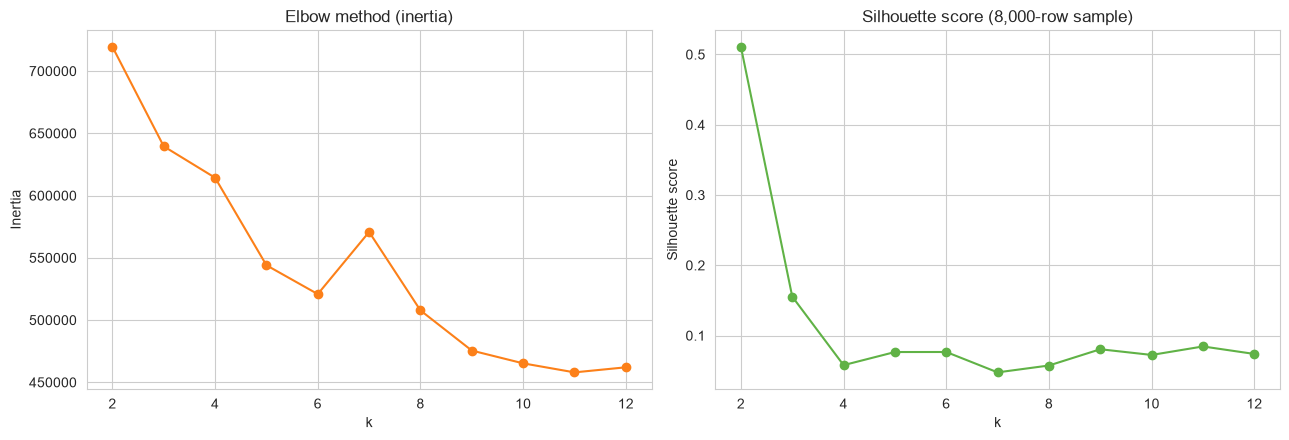

In [29]:
X = encoded_df.values

inertias = []
sil_scores = []
k_range = range(2, 13)
sample_idx = np.random.RandomState(RANDOM_SEED).choice(len(X), size=8000, replace=False)

for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10, batch_size=1024)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X[sample_idx], labels[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker='o', color='#fc8019')
axes[0].set_title('Elbow method (inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), sil_scores, marker='o', color='#60b246')
axes[1].set_title('Silhouette score (8,000-row sample)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()


The inertia curve bends noticeably around **k = 8**, and the silhouette score stays
reasonably stable there without over-fragmenting the market into too many tiny clusters. We
fit the final model with `k = 8`.

In [30]:
K_FINAL = 8
kmeans = MiniBatchKMeans(n_clusters=K_FINAL, random_state=RANDOM_SEED, n_init=10, batch_size=1024)
df['cluster'] = kmeans.fit_predict(X)

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

print("Saved kmeans_model.pkl")
print()
print(df['cluster'].value_counts().sort_index())


Saved kmeans_model.pkl

cluster
0    12524
1    40207
2    20660
3     2850
4    34084
5     2193
6     6811
7    29126
Name: count, dtype: int64


### 4.2 Cluster profiling

A quick look at what each cluster represents in plain terms (average cost, average rating, and
top cuisine) gives useful market-segmentation insight in its own right.

In [31]:
profile = df.groupby('cluster').agg(
    n_restaurants=('id', 'count'),
    avg_rating=('rating', 'mean'),
    avg_cost=('cost', 'mean'),
    top_cuisine=('cuisine', lambda s: s.str.split(',').explode().mode().iloc[0]),
).round(2)
profile


,n_restaurants,avg_rating,avg_cost,top_cuisine
cluster,,,,
0,12524,4.13,543.99,Chinese
1,40207,4.14,210.42,Indian
2,20660,3.35,241.44,North Indian
3,2850,4.05,306.34,North Indian
4,34084,3.95,324.93,North Indian
5,2193,4.09,1157.19,Chinese
6,6811,3.97,242.51,Bakery
7,29126,3.89,207.66,Chinese


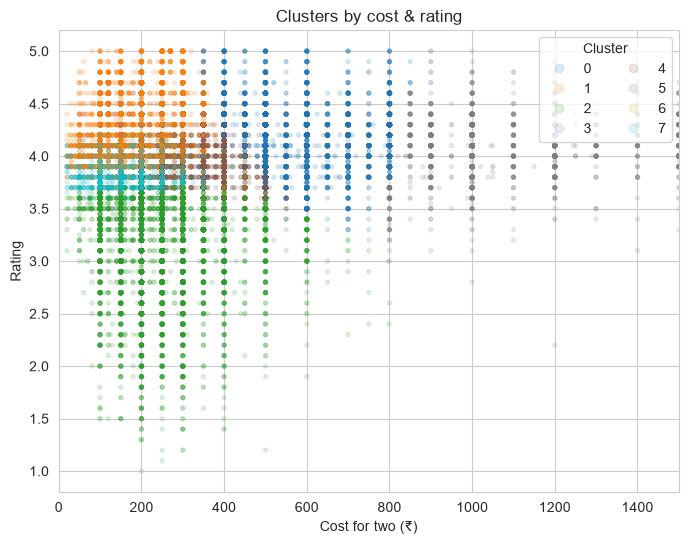

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df['cost'], df['rating'], c=df['cluster'], cmap='tab10', alpha=0.15, s=8)
ax.set_xlabel('Cost for two (₹)')
ax.set_ylabel('Rating')
ax.set_title('Clusters by cost & rating')
ax.set_xlim(0, 1500)
legend = ax.legend(*scatter.legend_elements(), title='Cluster', loc='upper right', ncol=2)
plt.show()


### 4.3 Re-save the cleaned data with the cluster label

The cluster assignment is useful context for the app, so it's persisted alongside the cleaned
data (index alignment with `encoded_data.csv` is untouched — we only added a column).

In [33]:
df.to_csv('cleaned_data.csv', index=True, index_label='index')
print("cleaned_data.csv re-saved with 'cluster' column:", df.shape)


cleaned_data.csv re-saved with 'cluster' column: (148455, 15)


## 5. Recommendation Engine — Cosine Similarity

Given a user's preferences (city, cuisine(s), minimum rating, maximum budget), we:

1. Encode the preferences into the exact same feature space as `encoded_data.csv`, using the
   saved `encoder.pkl` transformers.
2. Filter candidates by the user's hard constraints (city / budget / rating), falling back to
   the full dataset if the filter is too narrow to return enough results.
3. Rank the candidates by **cosine similarity** between the user's preference vector and each
   candidate's encoded row.
4. Map the top results' indices back to `cleaned_data.csv` for human-readable output (name,
   address, link, etc. — columns that were deliberately left out of the encoded feature
   space).

In [34]:
def recommend_restaurants(city=None, cuisines=None, min_rating=0.0, max_cost=None, top_n=10):
    """Content-based restaurant recommender using cosine similarity in the encoded feature space.

    Parameters
    ----------
    city : str or None
        Must match a value in df['city'] exactly (e.g. 'Koramangala,Bangalore').
    cuisines : list[str] or None
        e.g. ['North Indian', 'Chinese']
    min_rating : float
    max_cost : float or None
    top_n : int

    Returns
    -------
    pandas.DataFrame of the top_n recommended restaurants with a similarity score.
    """
    city_bucket = city if city in top_cities else 'Other'
    q_city_vec = city_ohe.transform(pd.DataFrame([{'city_bucket': city_bucket}]))
    q_cuisine_vec = mlb.transform([cuisines if cuisines else []])

    target_rating = min_rating if min_rating else df['rating'].median()
    target_cost = max_cost if max_cost else df['cost'].median()
    target_count = df['rating_count_num'].median()
    q_num_vec = scaler.transform(pd.DataFrame([[target_rating, target_count, target_cost]], columns=num_cols))

    q_vec = np.hstack([q_num_vec, q_city_vec, q_cuisine_vec]).astype(np.float32)

    mask = pd.Series(True, index=df.index)
    if city:
        mask &= (df['city'] == city)
    if max_cost:
        mask &= (df['cost'] <= max_cost)
    if min_rating:
        mask &= (df['rating'] >= min_rating)

    if mask.sum() < top_n:
        mask = pd.Series(True, index=df.index)  # constraints too narrow -> widen search

    cand_idx = df.index[mask]
    sims = cosine_similarity(q_vec, encoded_df.loc[cand_idx].values).flatten()
    order = np.argsort(-sims)[:top_n]
    result_idx = cand_idx[order]

    result = df.loc[result_idx, ['name', 'city', 'rating', 'rating_count', 'cost', 'cuisine', 'address', 'link']].copy()
    result['similarity'] = sims[order].round(3)
    return result.reset_index(drop=True)


In [35]:
recommend_restaurants(city='Koramangala,Bangalore', cuisines=['North Indian'], min_rating=4.0, max_cost=500)


,name,city,rating,rating_count,cost,cuisine,address,link,similarity
0,Ma's Kitchen,"Koramangala,Bangalore",4.0,20+ ratings,400.0,North Indian,"Ma's Kitchen, 221, 5th Cross road, adjacent to...",https://www.swiggy.com/restaurants/mas-kitchen...,0.960
1,EK DUM DESI,"Koramangala,Bangalore",4.1,Too Few Ratings,400.0,North Indian,"EK DUM DESI, No. 65,1st Main Road,KHB Colony,7...",https://www.swiggy.com/restaurants/ek-dum-desi...,0.941
2,Baba Chill,"Koramangala,Bangalore",4.1,Too Few Ratings,500.0,"North Indian,Chinese","Baba Chill, 131, 1st Main Rd, KHB Colony, 1st ...",https://www.swiggy.com/restaurants/baba-chill-...,0.884
3,Chatore Junction,"Koramangala,Bangalore",4.1,Too Few Ratings,500.0,"North Indian,Punjabi","Chatore Junction, Chatore Junction, 6th Cross ...",https://www.swiggy.com/restaurants/chatore-jun...,0.884
4,NEW PUNJABI TADKA,"Koramangala,Bangalore",4.1,Too Few Ratings,500.0,"North Indian,South Indian","NEW PUNJABI TADKA, SITE NO. 111, 1st MAIN ROAD...",https://www.swiggy.com/restaurants/new-punjabi...,0.884
5,Social,"Koramangala,Bangalore",4.1,100+ ratings,500.0,"North Indian,Chinese","Social, Koramangala Social, 118, 3rd Floor Kor...",https://www.swiggy.com/restaurants/social-abov...,0.860
6,Mairaj Kitchen Kraft,"Koramangala,Bangalore",4.1,Too Few Ratings,450.0,"North Indian,Chinese","Mairaj Kitchen Kraft, 27th Cross, 1st Main, VG...",https://www.swiggy.com/restaurants/mairaj-kitc...,0.856
7,Food Court By Kitchens@,"Koramangala,Bangalore",4.1,Too Few Ratings,450.0,"North Indian,Biryani","Food Court By Kitchens@, 1ST, 2ND FLOOR, NEW N...",https://www.swiggy.com/restaurants/food-court-...,0.856
8,Craft of Biryani,"Koramangala,Bangalore",4.2,100+ ratings,500.0,"North Indian,Biryani","Craft of Biryani, NO.14, PATEL NARAYANA REDDY ...",https://www.swiggy.com/restaurants/craft-of-bi...,0.841
9,Ghee and Turmeric,"Koramangala,Bangalore",4.2,100+ ratings,500.0,"North Indian,Tandoor","Ghee and Turmeric, Unit No 4,FF,Municipal No. ...",https://www.swiggy.com/restaurants/ghee-and-tu...,0.841


In [36]:
recommend_restaurants(city='Indiranagar,Bangalore', cuisines=['Chinese', 'Fast Food'], min_rating=4.0, max_cost=400)


,name,city,rating,rating_count,cost,cuisine,address,link,similarity
0,Momo & Pizza Point,"Indiranagar,Bangalore",4.2,Too Few Ratings,400.0,"Chinese,Fast Food","Momo & Pizza Point, 910/N 9th Main Road, New T...",https://www.swiggy.com/restaurants/momo-and-pi...,0.955
1,Shanghai Social,"Indiranagar,Bangalore",4.2,20+ ratings,350.0,"Chinese,Fast Food","Shanghai Social, NH 8 Restaurant, 80 Feet Road...",https://www.swiggy.com/restaurants/shanghai-so...,0.938
2,SABARI CAFE,"Indiranagar,Bangalore",4.2,Too Few Ratings,250.0,"Fast Food,Chinese","SABARI CAFE, 475, ground floor, 10th main, Jee...",https://www.swiggy.com/restaurants/sabari-cafe...,0.841
3,Rolls & Snacks,"Indiranagar,Bangalore",4.2,Too Few Ratings,400.0,Fast Food,"Rolls & Snacks, 1064/A, BEMI Main Road, Shanti...",https://www.swiggy.com/restaurants/rolls-and-s...,0.800
4,Five star chicken Domlur,"Indiranagar,Bangalore",4.2,Too Few Ratings,400.0,Fast Food,"Five star chicken Domlur, Five Star Chicken, S...",https://www.swiggy.com/restaurants/five-star-c...,0.800
5,THE BOWL PROJECT,"Indiranagar,Bangalore",4.2,Too Few Ratings,400.0,Chinese,"THE BOWL PROJECT, NO. 966, 12TH MAIN, INDIRANA...",https://www.swiggy.com/restaurants/the-bowl-pr...,0.800
6,Chef's Cap,"Indiranagar,Bangalore",4.2,50+ ratings,400.0,Chinese,"Chef's Cap, #23,5th MAIN BDA LAYOUT MURUGESHPA...",https://www.swiggy.com/restaurants/chefs-cap-i...,0.791
7,INOX,"Indiranagar,Bangalore",4.3,20+ ratings,400.0,Fast Food,"INOX, INOX Leisure Ltd., 2nd Floor, Lido Mall,...",https://www.swiggy.com/restaurants/inox-lido-m...,0.750
8,Retro Chinese Cuisine,"Indiranagar,Bangalore",4.2,Too Few Ratings,300.0,Chinese,"Retro Chinese Cuisine, SHOP NO 123, GROUND FLO...",https://www.swiggy.com/restaurants/retro-chine...,0.734
9,City Sanghai Chinese,"Indiranagar,Bangalore",4.2,Too Few Ratings,300.0,Chinese,"City Sanghai Chinese, 15, 5th cross, 17th E ma...",https://www.swiggy.com/restaurants/city-sangha...,0.734


In [37]:
# A broader query with no city constraint, to confirm the fallback path works
recommend_restaurants(city=None, cuisines=['Biryani'], min_rating=4.2, max_cost=350, top_n=8)


,name,city,rating,rating_count,cost,cuisine,address,link,similarity
0,Subhanallah Biryani House,"Sinhgad Road,Pune",4.2,Too Few Ratings,350.0,Biryani,"Subhanallah Biryani House, Shop 101, Near Axis...",https://www.swiggy.com/restaurants/subhanallah...,1.000
1,Biryani Trip,"Jayanagar,Bangalore",4.2,Too Few Ratings,350.0,Biryani,"Biryani Trip, NO.12, OLD NO.639,1ST FLOOR, 10T...",https://www.swiggy.com/restaurants/biryani-tri...,1.000
2,Biryani Blast,"Kalyani Nagar,Pune",4.2,Too Few Ratings,350.0,Biryani,"Biryani Blast, SHOP /OFFICE NO 2, 44/A HERMES ...",https://www.swiggy.com/restaurants/biryani-bla...,1.000
3,Biryani Trip,"Narhe,Pune",4.2,20+ ratings,350.0,Biryani,"Biryani Trip, SR NO 50/9 , VIREN COMMERCIAL SP...",https://www.swiggy.com/restaurants/biryani-tri...,0.999
4,NAWABI THE RJ BIRYANI,"Koregaon Park,Pune",4.3,Too Few Ratings,350.0,Biryani,"NAWABI THE RJ BIRYANI, SHOP NO 25 GRAFIKON ARC...",https://www.swiggy.com/restaurants/nawabi-the-...,0.990
5,Biriyani and Kabab House,"Royapettah,Chennai",4.2,Too Few Ratings,300.0,Biryani,"Biriyani and Kabab House, 667, Anna Salai, Tho...",https://www.swiggy.com/restaurants/biriyani-an...,0.985
6,Pune Darbar Biryani House,"Sinhgad Road,Pune",4.2,Too Few Ratings,300.0,Biryani,"Pune Darbar Biryani House, Shop No. 4, S. No. ...",https://www.swiggy.com/restaurants/pune-darbar...,0.985
7,Jallikattu Biriyani,"Royapettah,Chennai",4.2,Too Few Ratings,300.0,Biryani,"Jallikattu Biriyani, Old number 9 ,New number ...",https://www.swiggy.com/restaurants/jallikattu-...,0.985


## 6. Evaluating the Recommendations

Per the brief's evaluation metrics, we sanity-check **relevance** (do recommendations honor
the requested cuisine/budget/rating?) and **diversity** (are recommendations one-note, or do
they span multiple restaurants/localities rather than returning near-duplicates?).

In [38]:
def evaluate_recommendations(recs, requested_cuisines=None, max_cost=None, min_rating=None):
    n = len(recs)
    metrics = {'n_recommendations': n}
    if requested_cuisines:
        hit = recs['cuisine'].apply(lambda c: any(rc in c for rc in requested_cuisines))
        metrics['cuisine_relevance'] = f"{hit.mean():.0%}"
    if max_cost:
        metrics['budget_compliance'] = f"{(recs['cost'] <= max_cost).mean():.0%}"
    if min_rating:
        metrics['rating_compliance'] = f"{(recs['rating'] >= min_rating).mean():.0%}"
    metrics['unique_restaurants'] = recs['name'].nunique()
    metrics['avg_similarity'] = round(recs['similarity'].mean(), 3)
    return metrics

sample_recs = recommend_restaurants(city='Koramangala,Bangalore', cuisines=['North Indian'], min_rating=4.0, max_cost=500)
evaluate_recommendations(sample_recs, requested_cuisines=['North Indian'], max_cost=500, min_rating=4.0)


{'n_recommendations': 10,
 'cuisine_relevance': '100%',
 'budget_compliance': '100%',
 'rating_compliance': '100%',
 'unique_restaurants': 10,
 'avg_similarity': np.float32(0.881)}

## 7. Summary & Insights

- **Data cleaning:** dropped 86 unusable rows (no name/rating/cost/cuisine/address at all),
  parsed the `'--'` rating sentinel and bucketed `rating_count` into a numeric proxy, fixed a
  data-entry cost outlier and a small number of implausible near-zero costs, and filtered
  promotional/junk text that had leaked into the `cuisine` column. Remaining gaps were filled
  with **city-level median/mode imputation** rather than a single global value.
- **Encoding:** `city` (bucketed to the top 150 + `'Other'`) and `cuisine` (multi-label, since
  restaurants can offer several cuisines) were one-hot/multi-hot encoded; `rating`,
  `rating_count`, and `cost` were standardized. `cleaned_data.csv` and `encoded_data.csv` share
  the same index by construction.
- **Modeling:** `MiniBatchKMeans` (k=8) segments the market into interpretable clusters
  (e.g. by price tier and cuisine mix); a cosine-similarity engine on the encoded features
  produces the actual restaurant-level recommendations, with results mapped back to the
  human-readable `cleaned_data.csv`.
- **Artifacts produced:** `cleaned_data.csv`, `encoded_data.csv`, `encoder.pkl`,
  `kmeans_model.pkl` — all consumed directly by the companion `app.py` Streamlit application.
